# 🌳 Random Forest Classifier — Heart Disease Prediction
### A Step-by-Step Teaching Notebook

This notebook walks through a complete machine-learning pipeline using **Random Forest** to predict heart disease.  
By the end you will understand:
- What Random Forest is and *why* it works
- How to prepare data for a classifier
- How to train, evaluate, and improve a Random Forest model

---

## 0 · What Is a Random Forest?

A **Random Forest** is an *ensemble* method — it builds many decision trees and lets them vote on the final prediction.

```
         Training Data
              │
    ┌─────────┼─────────┐
    ▼         ▼         ▼
  Tree 1    Tree 2    Tree 3   ← each tree sees a random subset of data & features
    │         │         │
  "Yes"     "No"     "Yes"
    └─────────┼─────────┘
              │
          Majority Vote
              │
           "Yes" ✅
```

**Key ideas:**
| Concept | Meaning |
|---|---|
| **Bagging** | Each tree is trained on a *bootstrap* (random sample with replacement) of the data |
| **Feature randomness** | At each split, only a *random subset* of features is considered |
| **Majority vote** | Final prediction = class chosen by the most trees |

###  **Why does this help?** 
 > Individual trees overfit easily. By averaging many diverse trees, the forest's errors cancel out — giving lower variance and better generalisation.

---

## 1 · Load & Explore the Dataset

We use the **Heart Disease dataset** — a classic binary-classification benchmark.  
Each row is a patient; the `target` column is **1 = disease present**, **0 = no disease**.

**Dataset columns at a glance:**

| Feature | Description |
|---|---|
| `age` | Age in years |
| `sex` | 1 = male, 0 = female |
| `cp` | Chest pain type (0–3) |
| `trestbps` | Resting blood pressure |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl |
| `restecg` | Resting ECG results |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina |
| `oldpeak` | ST depression induced by exercise |
| `slope` | Slope of peak exercise ST segment |
| `ca` | Number of major vessels coloured by fluoroscopy |
| `thal` | Thalassemia type |
| `target` | **Label** — 1 = heart disease, 0 = no heart disease |

In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Consistent styling for all plots
sns.set_theme(style="whitegrid", palette="muted")

In [24]:
df = pd.read_csv('data_heart_disease.csv')
# df = pd.read_csv('https://raw.githubusercontent.com/ash322ash422/data/refs/heads/main/data_heart_disease.csv')

df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,NaN,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [25]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (303, 14)


In [26]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,NaN,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### 1a · Quick Look at the Target Distribution

Before modelling, always check whether the dataset is **balanced**.  
If one class dominates, your model might simply predict that class every time!

In [27]:
target_counts = df['target'].value_counts()
target_counts

target
1    165
0    138
Name: count, dtype: int64

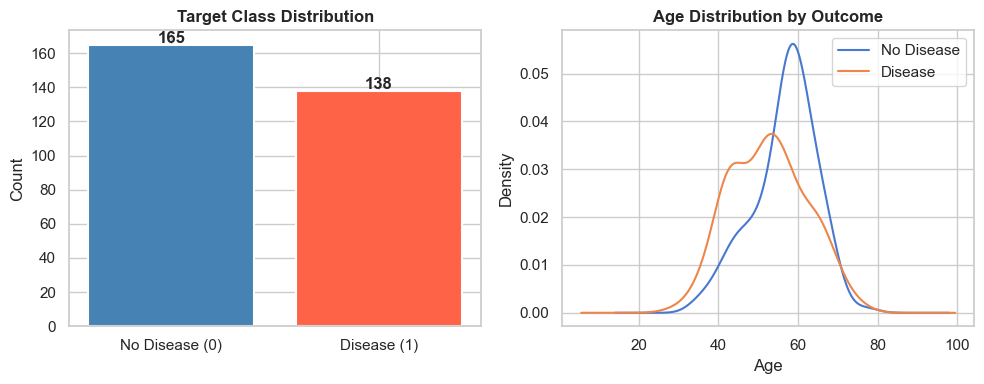

In [28]:
# Lets visualize

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Target balance
target_counts = df['target'].value_counts()
axes[0].bar(['No Disease (0)', 'Disease (1)'], target_counts.values,
            color=['steelblue', 'tomato'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Age distribution by target
df.groupby('target')['age'].plot(kind='kde', ax=axes[1], legend=True)
axes[1].set_title('Age Distribution by Outcome', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].legend(['No Disease', 'Disease'])

plt.tight_layout()
plt.show()

# 2 EDA - univariate / bivariate / multivariate 

## 3 · Split Features (X) and Labels (y)

We separate:
- **X** — the input features the model learns *from*
- **y** — the output label the model tries to *predict*

In [29]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,NaN,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [30]:
X = df.drop(columns=['target'])   # everything except the label
y = df['target']                   # the label

print(f"Features  X: {X.shape}")
print(f"Labels    y: {y.shape}")
print(f"\nFeature names: {list(X.columns)}")

Features  X: (303, 13)
Labels    y: (303,)

Feature names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [31]:
X
# y 

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,NaN,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


### 3a · Feature Correlation Heatmap

Understanding which features are correlated with each other (and with the target)
helps us interpret the model later.

In [32]:
corr = df.corr()
corr

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.071734,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.066903,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.071734,-0.066903,1.000000,0.037791,-0.076632,0.071332,0.065765,0.322889,-0.384238,-0.126206,0.128010,-0.167790,-0.136647,0.439651
trestbps,0.279351,-0.056769,0.037791,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076632,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.071332,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.065765,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.322889,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.384238,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.126206,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


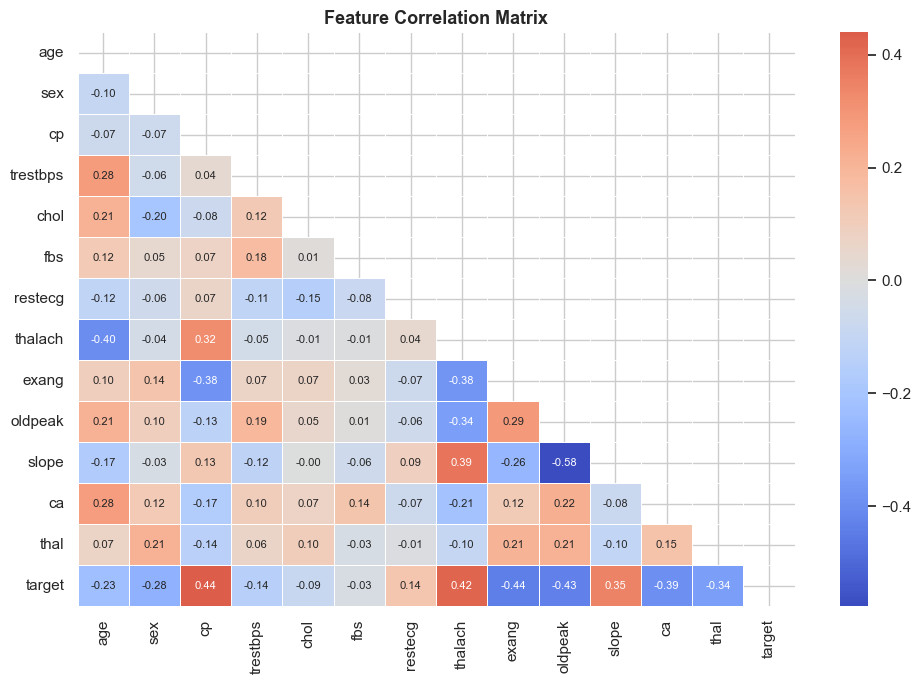


Top features correlated with 'target':
cp          0.439651
exang       0.436757
oldpeak     0.430696
thalach     0.421741
ca          0.391724
slope       0.345877
thal        0.344029
sex         0.280937
age         0.225439
trestbps    0.144931
restecg     0.137230
chol        0.085239
fbs         0.028046


In [33]:
# Heatmap allows you to read above numbers visually
fig, ax = plt.subplots(figsize=(10, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # show only lower triangle

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Highlight features most correlated with target
print("\nTop features correlated with 'target':")
print(corr['target'].drop('target').abs().sort_values(ascending=False).to_string())

## 4 · Train / Test Split

We split the data into:
- **Training set (80%)** — used to fit (teach) the model
- **Test set (20%)** — held out to evaluate how well the model generalises

> `random_state=42` makes the split reproducible — running it again gives the same split.

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")

Training samples : 242
Test samples     : 61


## Handle Missing Values - Idelly should be done after splitting to avoid data leakage 

Real-world data is almost never perfect.  
We check for `NaN` values and **impute** them (fill in a sensible replacement) rather than dropping rows.

> **Why impute instead of dropping?**  
> Dropping rows loses information. Imputing with the **mean** is a simple, defensible strategy for continuous numeric features.

> ⚠️ In a production system you'd explore more sophisticated strategies (**median for skewed data**, model-based imputation, etc.).

In [35]:
# 1) Which columns have missing values?

missing = X_train.isnull().sum()
print("Missing values in train per column:\n", missing)


missing = X_test.isnull().sum()
print("\nMissing values in test per column:\n", missing)

Missing values in train per column:
 age          0
sex          0
cp          10
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
dtype: int64

Missing values in test per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64


In [36]:
# 2) Handle missing value
from sklearn.impute import SimpleImputer

# Mean imputation — suitable for numeric, roughly-normal features
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

# Fit AND transform the training data (learns the train mean)
X_train_imputed = imputer.fit_transform(X_train)
X_train = pd.DataFrame(X_train_imputed, columns=X_train.columns)

# ONLY transform the test data (uses the stored train mean)
X_test_imputed = imputer.transform(X_test)
X_test = pd.DataFrame(X_test_imputed, columns=X_test.columns)

In [37]:
# 3) verify missing values are gone
missing = X_train.isnull().sum()
print("Missing values in train per column:\n", missing)


missing = X_test.isnull().sum()
print("\nMissing values in test per column:\n", missing)

Missing values in train per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64

Missing values in test per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64


## 5 · Train the Random Forest

### Key hyperparameters

| Parameter | What it controls |
|---|---|
| `n_estimators` | Number of trees in the forest — more trees = more stable, but slower |
| `max_depth` | Maximum depth of each tree — `None` = grow until pure |
| `min_samples_split` | Minimum samples required to split a node |
| `max_features` | Number of features considered at each split (`sqrt` is the default for classifiers) |
| `random_state` | Seed for reproducibility |

> **Rule of thumb:** Start with `n_estimators=100`. More trees rarely hurt accuracy but do increase training time.

In [38]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"   Trees in forest : {model.n_estimators}")
print(f"   Features used   : {model.n_features_in_}")

Model trained successfully!
   Trees in forest : 100
   Features used   : 13


In [39]:
# Lets test on a sample:
print(list(X_test.iloc[0]))
print(y_test.iloc[0])

[57.0, 1.0, 0.0, 150.0, 276.0, 0.0, 0.0, 112.0, 1.0, 0.6, 1.0, 1.0, 1.0]
0


In [40]:
sample = [[57.0, 1.0, 0.0, 150.0, 276.0, 0.0, 0.0, 112.0, 1.0, 0.6, 1.0, 1.0, 1.0]]

y_pred = model.predict(sample)
y_pred

C:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([0])

## 6 · Evaluate the Model

### 6a · Overall Accuracy

Accuracy = (correct predictions) / (total predictions)

> Accuracy alone can be misleading on imbalanced datasets — always pair it with a confusion matrix.

In [27]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.2%}\n")

print("Full Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

Test Accuracy: 80.33%

Full Classification Report:
              precision    recall  f1-score   support

  No Disease       0.77      0.83      0.80        29
     Disease       0.83      0.78      0.81        32

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.81      0.80      0.80        61



### 6b · Confusion Matrix

The **confusion matrix** shows exactly where the model gets it right and where it makes mistakes.

```
                  Predicted
                No Disease  Disease
Actual No Disease  [TN]      [FP]
       Disease     [FN]      [TP]
```

- **TN** True Negative — correctly predicted no disease  
- **TP** True Positive — correctly predicted disease  
- **FP** False Positive — predicted disease, but patient is healthy *(false alarm)*  
- **FN** False Negative — missed a real disease case *(most dangerous in medical context)*

In [32]:
print("actual :", list(y_test)[:10])
print("predict:", list(y_pred)[:10])

actual : [0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0]
predict: [0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0]


confusion matrix:
 [[24  5]
 [ 7 25]]


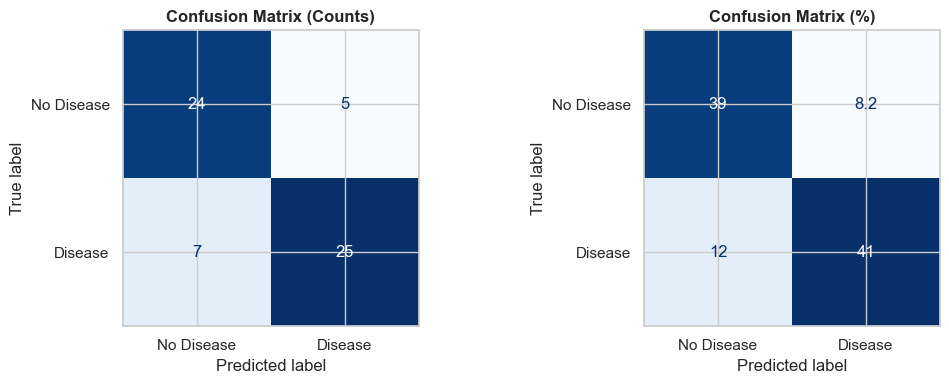

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print("confusion matrix:\n", cm)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Raw counts
disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')

# Normalised (percentages)
cm_norm = cm.astype(float) / cm.sum()
disp2 = ConfusionMatrixDisplay(np.round(cm_norm * 100, 1), display_labels=['No Disease', 'Disease'])
disp2.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix (%)', fontweight='bold')

plt.tight_layout()
plt.show()

## 7 · Feature Importance

One of Random Forest's biggest strengths is **interpretability** — we can ask *which features drove the predictions?*

Each feature is assigned an importance score based on how much it reduced impurity (Gini / entropy) across all trees.

> Higher importance → the feature was more useful for making decisions across the forest.

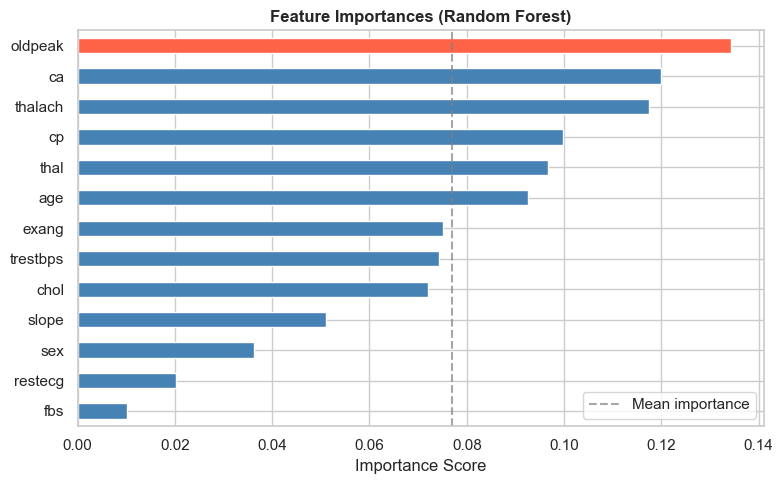


Top 5 most important features:
oldpeak    0.134281
ca         0.119897
thalach    0.117469
cp         0.099752
thal       0.096695
dtype: float64


In [33]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tomato' if v == importances.max() else 'steelblue' for v in importances.values]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importances (Random Forest)', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(importances.mean(), color='gray', linestyle='--', alpha=0.7, label='Mean importance')
ax.legend()
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importances.sort_values(ascending=False).head())

## 8 · Hyperparameter Tuning with Grid Search

The default settings are good, but we can do better by **systematically searching** for the best combination of hyperparameters.

**GridSearchCV** tries every combination in a grid and uses **k-fold cross-validation** to evaluate each — avoiding overfitting to a single train/test split.

> ⏱️ This cell may take a few minutes. Set `verbose=1` to see progress.

```
param_grid = {
  n_estimators:      [100, 200, 300]   →  3 choices
  max_depth:         [None, 5, 10, 20] →  4 choices
  min_samples_split: [2, 5, 10]        →  3 choices
  min_samples_leaf:  [1, 2, 4]         →  3 choices
  max_features:      ['sqrt', 'log2']  →  2 choices
}
Total combinations = 3×4×3×3×2 = 216
With 5-fold CV → 216 × 5 = 1080 fits
```

In [32]:
# Took 
from sklearn.model_selection import GridSearchCV

# Took 20 + minute
# param_grid = {
#     'n_estimators'    : [100, 200, 300],
#     'max_depth'       : [None, 5, 10, 20],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf' : [1, 2, 4],
#     'max_features'    : ['sqrt', 'log2']
# }

# Took 1 minute
param_grid = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [5, 10, ],
    'min_samples_split': [2, 3,],
    'min_samples_leaf' : [1, 2],
    'max_features'    : ['sqrt',]
}



grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_grid = param_grid,
    cv         = 5,            # 5-fold cross-validation
    scoring    = 'accuracy',
    n_jobs     = -1,           # use all CPU cores
    verbose    = 1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10], 'max_features': ['sqrt'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 3],
                         'n_estimators': [100, 200]},
             scoring='accuracy', verbose=1)

In [33]:
best_model = grid_search.best_estimator_
best_acc   = best_model.score(X_test, y_test)

print("Best Hyperparameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k:25s}: {v}")

print(f"\nBaseline accuracy  : {accuracy:.2%}")
print(f"Tuned model accuracy: {best_acc:.2%}")
print(f"Improvement        : +{(best_acc - accuracy)*100:.1f} pp")

Best Hyperparameters:
  max_depth                : 5
  max_features             : sqrt
  min_samples_leaf         : 2
  min_samples_split        : 2
  n_estimators             : 200

Baseline accuracy  : 80.33%
Tuned model accuracy: 85.25%
Improvement        : +4.9 pp


## 9 · Summary & Key Takeaways

| Step | What we did | Why |
|---|---|---|
| **EDA** | Checked class balance, distributions | Know your data before modelling |
| **Imputation** | Filled missing `cp` values with column mean | Preserves all rows; sensible for numeric data |
| **Train/Test split** | 80 / 20 | Evaluate on data the model has never seen |
| **Random Forest** | 100 trees, majority vote | Robust, low-variance ensemble |
| **Confusion Matrix** | TN / FP / FN / TP breakdown | Accuracy alone is not enough |
| **Feature Importance** | Ranked input features | Interpretability + potential feature selection |
| **Grid Search CV** | Searched 216 hyperparameter combos | Squeeze extra performance systematically |

### Random Forest — Pros & Cons

| ✅ Pros | ❌ Cons |
|---|---|
| Handles missing data well | Slower than a single tree |
| Robust to outliers | Less interpretable than one decision tree |
| Built-in feature importance | High memory use with many trees |
| Rarely overfits | Hyperparameter tuning is expensive |
| No feature scaling needed | — |

